In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from datetime import datetime
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

import torch
print(f"GPU: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import Dataset
import shutil
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM 
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments,DataCollatorForSeq2Seq
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding

GPU: True
GPU: Tesla T4


# Dataset Overview

**Dataset SAFN:** https://www.kaggle.com/datasets/ankurzing/sentiment-analysis-for-financial-news

This dataset contains the sentiments for financial news headlines from the perspective of a retail investor. Further details about the dataset can be found in: Malo, P., Sinha, A., Takala, P., Korhonen, P. and Wallenius, J. (2014): “Good debt or bad debt: Detecting semantic orientations in economic texts.” Journal of the American Society for Information Science and Technology.

**Dataset SEntFiN:** https://www.kaggle.com/datasets/ankurzing/aspect-based-sentiment-analysis-for-financial-news

This file contains 10,700+ news headlines for which we have sentiment annotations for all the financial entities that appear in the headlines. Further details about the dataset can be found in: Sinha, A., Kedas, S., Kumar, R., & Malo, P. (2022). SEntFiN 1.0: Entity‐aware sentiment analysis for financial news. Journal of the Association for Information Science and Technology.


In [2]:
SAFN = pd.read_csv('/kaggle/input/datasets/ankurzing/sentiment-analysis-for-financial-news/all-data.csv', 
                 encoding='latin-1',
                 header=None, 
                 names=['sentiment', 'title'])
SAFN.head()

,sentiment,title
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [3]:
SEntFiN = pd.read_csv('/kaggle/input/datasets/ankurzing/aspect-based-sentiment-analysis-for-financial-news/SEntFiN-v1.1.csv', 
                 encoding='latin-1')

SEntFiN = SEntFiN.drop('S No.', axis=1)
SEntFiN = SEntFiN.drop('Words', axis=1)

def extract_sentiment(text):
    if pd.isna(text):
        return None
    
    # neutral/positive/negative
    if 'neutral' in text.lower():
        return 'neutral'
    elif 'positive' in text.lower():
        return 'positive'
    elif 'negative' in text.lower():
        return 'negative'
    else:
        return None

SEntFiN['sentiment'] = SEntFiN['Decisions'].apply(extract_sentiment)
SEntFiN = SEntFiN.drop('Decisions', axis=1)

SEntFiN = SEntFiN.rename(columns={
    'Title': 'title'
})

SEntFiN = SEntFiN[['sentiment', 'title']]
SEntFiN.head()

,sentiment,title
0,neutral,SpiceJet to issue 6.4 crore warrants to promoters
1,neutral,MMTC Q2 net loss at Rs 10.4 crore
2,positive,"Mid-cap funds can deliver more, stay put: Experts"
3,positive,Mid caps now turn into market darlings
4,neutral,"Market seeing patience, if not conviction: Pra..."


In [4]:
def clean_and_prepare_data(df):
    df_clean = df.copy()
    
    df_clean = df_clean.dropna()
    df_clean = df_clean.reset_index(drop=True)
    
    if 'text' in df_clean.columns:
        df_clean['text'] = df_clean['text'].str.strip()
    
    # negative-0, neutral-1, positive-2
    label_encoder = LabelEncoder()
    
    if 'sentiment' in df_clean.columns:
        valid_labels = ['negative', 'neutral', 'positive']
        df_clean = df_clean[df_clean['sentiment'].isin(valid_labels)]

        df_clean['label'] = label_encoder.fit_transform(df_clean['sentiment'])
        
    else:
        print("No'sentiment'")
    
    print(f"Dataset Size: {df_clean.shape}")
    
    return df_clean
    
SAFN = clean_and_prepare_data(SAFN)
SEntFiN = clean_and_prepare_data(SEntFiN)

Dataset Size: (4846, 3)
Dataset Size: (10753, 3)


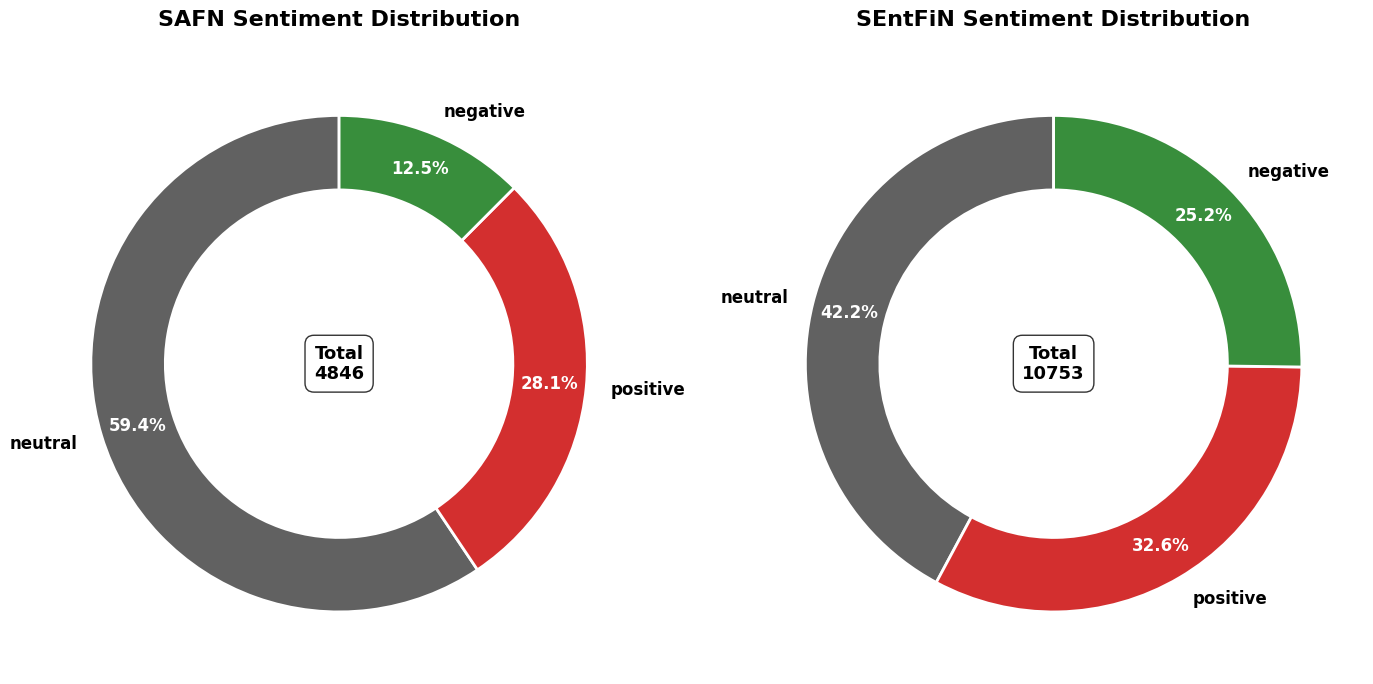

In [5]:
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11
})

colors = ['#616161', '#D32F2F', '#388E3C'] 

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

sentiment_counts_SAFN = SAFN['sentiment'].value_counts()
wedges1, texts1, autotexts1 = axes[0].pie(
    sentiment_counts_SAFN.values, 
    labels=sentiment_counts_SAFN.index,
    autopct='%1.1f%%', 
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.3},
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    pctdistance=0.85
)

for autotext in autotexts1:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

axes[0].set_title('SAFN Sentiment Distribution', fontsize=16, fontweight='bold', pad=20)

total_SAFN = SAFN.shape[0]
axes[0].text(0, 0, f'Total\n{total_SAFN}', 
             ha='center', va='center', 
             fontsize=13, fontweight='bold', 
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

sentiment_counts_SEntFiN = SEntFiN['sentiment'].value_counts()
wedges2, texts2, autotexts2 = axes[1].pie(
    sentiment_counts_SEntFiN.values, 
    labels=sentiment_counts_SEntFiN.index,
    autopct='%1.1f%%', 
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.3},
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    pctdistance=0.85
)

for autotext in autotexts2:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

axes[1].set_title('SEntFiN Sentiment Distribution', fontsize=16, fontweight='bold', pad=20)

total_SEntFiN = SEntFiN.shape[0]
axes[1].text(0, 0, f'Total\n{total_SEntFiN}', 
             ha='center', va='center', 
             fontsize=13, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

#plt.suptitle('Sentiment Distribution Comparison', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('sentiment_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Data Split & Evaluation Matrix

In [6]:
def simple_split_dataset(df, label_col='label', test_size=0.3, val_size=0.5, random_state=42):

    df_train, df_temp = train_test_split(
        df, 
        test_size=test_size,
        random_state=random_state,
        stratify=df[label_col]
    )

    df_val, df_test = train_test_split(
        df_temp,
        test_size=val_size,
        random_state=random_state,
        stratify=df_temp[label_col]
    )
    
    print(f"Training set: {df_train.shape[0]} samples")
    print(f"Validation set: {df_val.shape[0]} samples")
    print(f"Test set: {df_test.shape[0]} samples")
    
    return df_train, df_val, df_test

In [7]:
SAFN_train, SAFN_val, SAFN_test = simple_split_dataset(SAFN, label_col='label', test_size=0.3, val_size=0.5, random_state=42)

Training set: 3392 samples
Validation set: 727 samples
Test set: 727 samples


In [8]:
SEntFiN_train, SEntFiN_val, SEntFiN_test = simple_split_dataset(SEntFiN, label_col='label', test_size=0.3, val_size=0.5, random_state=42)

Training set: 7527 samples
Validation set: 1613 samples
Test set: 1613 samples


In [9]:
def evaluate_model(y_true, y_pred, y_pred_proba=None, average='macro'):

    results = {}

    results['Accuracy'] = accuracy_score(y_true, y_pred)
    results['Macro_Precision'] = precision_score(y_true, y_pred, average=average)
    results['Macro_Recall'] = recall_score(y_true, y_pred, average=average)
    results['Macro_F1'] = f1_score(y_true, y_pred, average=average)
    
    # Specificity
    cm = confusion_matrix(y_true, y_pred)
    specificity_scores = []
    for i in range(cm.shape[0]):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_scores.append(specificity)
    results['Macro_Specificity'] = np.mean(specificity_scores)
    
    # AUC & AUPRC
    if y_pred_proba is not None:
        try:
            # One-vs-Rest ROC AUC
            results['Macro_AUC'] = roc_auc_score(y_true, y_pred_proba, average=average, multi_class='ovr')
            # One-vs-Rest AUPRC
            results['Macro_AUPRC'] = average_precision_score(y_true, y_pred_proba, average=average)
        except:
            results['Macro_AUC'] = None
            results['Macro_AUPRC'] = None
    
    return results

In [10]:
from sklearn.metrics import roc_curve, auc

def save_roc_data_for_plotting(model_name, dataset_split, y_true, y_pred_proba, 
                              csv_filepath='roc_plotting_data.csv'):
    
    if dataset_split.lower() != 'test':
        return
    
    try:
        n_classes = y_pred_proba.shape[1]

        if n_classes == 3:
            class_names = ['negative', 'neutral', 'positive']  # 0, 1, 2
        else:
            class_names = [f'Class_{i}' for i in range(n_classes)]
        
        data_to_save = []
        
        for class_idx in range(n_classes):
            # One-vs-Rest
            y_true_binary = (y_true == class_idx).astype(int)
            y_score = y_pred_proba[:, class_idx]
            
            # ROC
            fpr, tpr, _ = roc_curve(y_true_binary, y_score)
            roc_auc = auc(fpr, tpr)
            
            for fp_rate, tp_rate in zip(fpr, tpr):
                data_to_save.append({
                    'model': model_name,
                    'class_index': class_idx,
                    'class_name': class_names[class_idx],
                    'fpr': fp_rate,
                    'tpr': tp_rate,
                    'auc': roc_auc
                })

        df_roc = pd.DataFrame(data_to_save)

        if not os.path.exists(csv_filepath):
            df_roc.to_csv(csv_filepath, index=False)
        else:
            df_roc.to_csv(csv_filepath, mode='a', header=False, index=False)
        
        print(f"[ROC Data Saving] Model '{model_name}' ROC data saved to {csv_filepath}")
        print(f"  Classes: {class_names}")
        print(f"  Data points: {len(df_roc)} rows")
        
    except Exception as e:
        print(f"[Warning] Failed to save ROC data for model '{model_name}': {e}")

In [11]:
def save_confusion_data(model_name, dataset_split, y_true, y_pred, csv_filepath='confusion_data.csv'):

    data = {
        'model': [model_name] * len(y_true),
        'dataset_split': [dataset_split] * len(y_true),
        'true_label': y_true,
        'pred_label': y_pred
    }
    
    df = pd.DataFrame(data)

    if os.path.exists(csv_filepath):
        existing_df = pd.read_csv(csv_filepath)
        df = pd.concat([existing_df, df], ignore_index=True)

    df.to_csv(csv_filepath, index=False)
    print(f"✅ Confusion data saved: {csv_filepath} (model: {model_name}, split: {dataset_split})")

In [12]:
# def run_test_mode(train_data, val_data, test_data, test_size=50):
#     train_subset = train_data.head(test_size).copy()
#     val_subset = val_data.head(test_size).copy()
#     test_subset = test_data.head(test_size).copy()
    
#     return train_subset, val_subset, test_subset

# SAFN_train, SAFN_val, SAFN_test = run_test_mode(
#     SAFN_train, SAFN_val, SAFN_test, test_size=50
# )

# SEntFiN_train, SEntFiN_val, SEntFiN_test = run_test_mode(
#     SEntFiN_train, SEntFiN_val, SEntFiN_test, test_size=50
# )

# Baseline
## MLP+TF-IDF

In [13]:
def train_mlp_tfidf(df_train, df_val, df_test, text_col='title', label_col='label', model_save_path='models'):

    print("="*40)
    print("Baseline: MLP+TF-IDF")
    print("="*40)

    X_train = df_train[text_col].values
    y_train = df_train[label_col].values
    X_val = df_val[text_col].values
    y_val = df_val[label_col].values
    X_test = df_test[text_col].values
    y_test = df_test[label_col].values
    
    # final data
    X_all = np.concatenate([X_train, X_val, X_test])
    y_all = np.concatenate([y_train, y_val, y_test])
    
    # train
    mlp_pipeline_initial = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')),
        ('mlp', MLPClassifier(hidden_layer_sizes=(256, 128), 
                             activation='relu',
                             batch_size=32,
                             learning_rate_init=0.001,
                             max_iter=100,
                             random_state=42,
                             early_stopping=True,
                             validation_fraction=0.1))
    ])
    
    mlp_pipeline_initial.fit(X_train, y_train)
    
    # val & test
    y_pred_train = mlp_pipeline_initial.predict(X_train)
    y_pred_val = mlp_pipeline_initial.predict(X_val)
    y_pred_test = mlp_pipeline_initial.predict(X_test)
    
    y_pred_proba_train = mlp_pipeline_initial.predict_proba(X_train)
    y_pred_proba_val = mlp_pipeline_initial.predict_proba(X_val)
    y_pred_proba_test = mlp_pipeline_initial.predict_proba(X_test)
    
    results_train = evaluate_model(y_train, y_pred_train, y_pred_proba_train)
    results_val = evaluate_model(y_val, y_pred_val, y_pred_proba_val)
    results_test = evaluate_model(y_test, y_pred_test, y_pred_proba_test)
    
    # Exp1 results 
    print("train:")
    for metric, value in results_train.items():
        if isinstance(value, (int, float)):
            print(f"  {metric}: {value:.4f}")
        else:
            print(f"  {metric}: {value}")
    
    print("val:")
    for metric, value in results_val.items():
        if isinstance(value, (int, float)):
            print(f"  {metric}: {value:.4f}")
        else:
            print(f"  {metric}: {value}")
    
    print("test:")
    for metric, value in results_test.items():
        if isinstance(value, (int, float)):
            print(f"  {metric}: {value:.4f}")
        else:
            print(f"  {metric}: {value}")
    
    # final train
    mlp_pipeline_final = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')),
        ('mlp', MLPClassifier(hidden_layer_sizes=(256, 128), 
                             activation='relu',
                             batch_size=32,
                             learning_rate_init=0.001,
                             max_iter=100,
                             random_state=42,
                             early_stopping=True,
                             validation_fraction=0.1))
    ])

    mlp_pipeline_final.fit(X_all, y_all)
    print("\n" + "final training finished")
    # results prepare for Exp2
    # print("-"*40)
    # print("final results:")
    
    # y_pred_all = mlp_pipeline_final.predict(X_all)
    # y_pred_proba_all = mlp_pipeline_final.predict_proba(X_all)
    # results_final = evaluate_model(y_all, y_pred_all, y_pred_proba_all)
    
    # for metric, value in results_final.items():
    #     if isinstance(value, (int, float)):
    #         print(f"  {metric}: {value:.4f}")
    #     else:
    #         print(f"  {metric}: {value}")
    
    # save final model
    if not os.path.exists(model_save_path):
        os.makedirs(model_save_path)
    
    model_filename = f"mlp_tfidf.pkl"
    model_full_path = os.path.join(model_save_path, model_filename)
    joblib.dump(mlp_pipeline_final, model_full_path)
    print(f"✅ model saved successful: {model_full_path}")
    
    save_roc_data_for_plotting(
    model_name="mlp_TFIDF",
    dataset_split='test', 
    y_true=y_test,
    y_pred_proba=y_pred_proba_test,  
    csv_filepath=f'{model_save_path}/all_models_roc_data.csv' 
    )
    save_confusion_data(
    model_name="mlp_TFIDF",
    dataset_split='test', 
    y_true=y_test,
    y_pred=y_pred_test, 
    csv_filepath=f'{model_save_path}/all_models_confusion_data.csv' 
    )

print("="*40)
print('Dataset: SAFN')
train_mlp_tfidf(SAFN_train, SAFN_val, SAFN_test, text_col='title', label_col='label', model_save_path='SAFN')
print("\n"+"="*40)
print('Dataset: SEntFiN')
train_mlp_tfidf(SEntFiN_train, SEntFiN_val, SEntFiN_test, text_col='title', label_col='label', model_save_path='SEntFiN')

Dataset: SAFN
Baseline: MLP+TF-IDF
train:
  Accuracy: 0.9764
  Macro_Precision: 0.9734
  Macro_Recall: 0.9683
  Macro_F1: 0.9708
  Macro_Specificity: 0.9855
  Macro_AUC: 0.9940
  Macro_AUPRC: 0.9900
val:
  Accuracy: 0.7208
  Macro_Precision: 0.6530
  Macro_Recall: 0.6448
  Macro_F1: 0.6486
  Macro_Specificity: 0.8326
  Macro_AUC: 0.8298
  Macro_AUPRC: 0.7012
test:
  Accuracy: 0.6795
  Macro_Precision: 0.6124
  Macro_Recall: 0.6125
  Macro_F1: 0.6122
  Macro_Specificity: 0.8068
  Macro_AUC: 0.8160
  Macro_AUPRC: 0.6928

final training finished
✅ model saved successful: SAFN/mlp_tfidf.pkl
[ROC Data Saving] Model 'mlp_TFIDF' ROC data saved to SAFN/all_models_roc_data.csv
  Classes: ['negative', 'neutral', 'positive']
  Data points: 619 rows
✅ Confusion data saved: SAFN/all_models_confusion_data.csv (model: mlp_TFIDF, split: test)

Dataset: SEntFiN
Baseline: MLP+TF-IDF
train:
  Accuracy: 0.9280
  Macro_Precision: 0.9279
  Macro_Recall: 0.9262
  Macro_F1: 0.9271
  Macro_Specificity: 0.9628


## textCNN

In [14]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, filter_sizes=[3, 4, 5], num_filters=100):
        super(TextCNN, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        self.convs = nn.ModuleList([
            nn.Conv2d(1, num_filters, (fs, embed_dim))
            for fs in filter_sizes
        ])
        
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        x = x.unsqueeze(1)
        
        conv_results = []
        for conv in self.convs:
            conv_out = F.relu(conv(x)).squeeze(3)
            pool_out = F.max_pool1d(conv_out, conv_out.size(2)).squeeze(2)
            conv_results.append(pool_out)
        
        x = torch.cat(conv_results, 1)
        x = self.dropout(x)
        x = self.fc(x)
        
        return x


class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=100):
        if not isinstance(texts, list):
            if isinstance(texts, (pd.Series, np.ndarray)):
                texts = texts.tolist()
            else:
                texts = list(texts)
        
        if not isinstance(labels, list):
            if isinstance(labels, (pd.Series, np.ndarray)):
                labels = labels.tolist()
            else:
                labels = list(labels)
        
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        if isinstance(idx, (int, np.integer)):
            idx = int(idx)
            text = self.texts[idx]
            label = self.labels[idx]
            
            if isinstance(text, np.ndarray):
                try:
                    if text.ndim > 1:
                        text = ' '.join(str(x) for x in text.flatten())
                    else:
                        text = ' '.join(str(x) for x in text)
                except:
                    text = str(text)
            elif not isinstance(text, str):
                text = str(text)
            
            tokens = text.split()[:self.max_len]
            indices = [self.vocab.get(token, 0) for token in tokens]
            
            if len(indices) < self.max_len:
                indices += [0] * (self.max_len - len(indices))
            else:
                indices = indices[:self.max_len]
            
            return {
                'input_ids': torch.tensor(indices, dtype=torch.long),
                'labels': torch.tensor(label, dtype=torch.long)
            }

        if isinstance(idx, torch.Tensor):
            idx = idx.item()
            return self.__getitem__(idx)

        if isinstance(idx, (list, np.ndarray)):
            batch_result = {'input_ids': [], 'labels': []}
            for i in idx:
                if isinstance(i, torch.Tensor):
                    i = i.item()
                item = self.__getitem__(int(i))
                batch_result['input_ids'].append(item['input_ids'])
                batch_result['labels'].append(item['labels'])

            batch_result['input_ids'] = torch.stack(batch_result['input_ids'])
            batch_result['labels'] = torch.stack(batch_result['labels'])
            return batch_result

        idx = int(idx)
        return self.__getitem__(idx)


def train_textcnn(df_train, df_val, df_test, text_col='title', label_col='label', 
                  batch_size=32, epochs=20, lr=0.001, model_save_path='models'):
    print("="*40)
    print("Baseline: textCNN")
    print("="*40)

    if not isinstance(df_train, pd.DataFrame):
        df_train = pd.DataFrame(df_train)
    if not isinstance(df_val, pd.DataFrame):
        df_val = pd.DataFrame(df_val)
    if not isinstance(df_test, pd.DataFrame):
        df_test = pd.DataFrame(df_test)
    
    def convert_to_string_list(data):
        if isinstance(data, pd.Series):
            return data.astype(str).tolist()
        elif isinstance(data, np.ndarray):
            return [str(x) for x in data]
        elif isinstance(data, list):
            return [str(x) for x in data]
        else:
            return [str(data)]
    
    train_texts = convert_to_string_list(df_train[text_col])
    val_texts = convert_to_string_list(df_val[text_col])
    test_texts = convert_to_string_list(df_test[text_col])
    
    train_labels = df_train[label_col].tolist()
    val_labels = df_val[label_col].tolist()
    test_labels = df_test[label_col].tolist()
    
    all_texts = train_texts + val_texts + test_texts
    all_labels = train_labels + val_labels + test_labels
    
    vectorizer = CountVectorizer(max_features=10000)
    vectorizer.fit(train_texts)
    vocab = {word: idx+1 for idx, word in enumerate(vectorizer.get_feature_names_out())}
    vocab_size = len(vocab) + 1
    
    train_dataset = TextDataset(train_texts, train_labels, vocab)
    val_dataset = TextDataset(val_texts, val_labels, vocab)
    test_dataset = TextDataset(test_texts, test_labels, vocab)
    all_dataset = TextDataset(all_texts, all_labels, vocab)

    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=0,
        pin_memory=False
    )
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
    all_loader = DataLoader(all_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # initial training
    model = TextCNN(vocab_size, 100, num_classes=3)
    model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # training loop
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            texts = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss/len(train_loader):.4f}")
    
    # evaluate on train, val, test
    def evaluate_model_on_dataset(model, data_loader):
        model.eval()
        all_preds = []
        all_labels = []
        all_probs = []
        
        with torch.no_grad():
            for batch in data_loader:
                texts = batch['input_ids'].to(device)
                labels = batch['labels'].to(device)
                outputs = model(texts)
                probs = F.softmax(outputs, dim=1)
                
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
        
        return np.array(all_labels), np.array(all_preds), np.array(all_probs)
    
    y_train_true, y_train_pred, y_train_proba = evaluate_model_on_dataset(model, train_loader)
    y_val_true, y_val_pred, y_val_proba = evaluate_model_on_dataset(model, val_loader)
    y_test_true, y_test_pred, y_test_proba = evaluate_model_on_dataset(model, test_loader)
    
    results_train = evaluate_model(y_train_true, y_train_pred, y_train_proba)
    results_val = evaluate_model(y_val_true, y_val_pred, y_val_proba)
    results_test = evaluate_model(y_test_true, y_test_pred, y_test_proba)
    
    # Exp1 results
    print("train:")
    for k, v in results_train.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
    print("val:")
    for k, v in results_val.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
    print("test:")
    for k, v in results_test.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    print("\n")
    
    # final training
    model_final = TextCNN(vocab_size, 100, num_classes=3)
    model_final.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_final.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model_final.train()
        epoch_loss = 0
        for batch in DataLoader(all_dataset, batch_size=batch_size, shuffle=True):
            texts = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            
            optimizer.zero_grad()
            outputs = model_final(texts)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        print(f"Final Training Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(all_loader):.4f}")
    
    print("\n" + "final training finished")
    # results prepare for Exp2
    # y_all_true, y_all_pred, y_all_proba = evaluate_model_on_dataset(model_final, all_loader)
    # results_final = evaluate_model(y_all_true, y_all_pred, y_all_proba)
    
    # print("-"*40)
    # print("final results:")
    # for k, v in results_final.items():
    #     print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
    # save model
    if not os.path.exists(model_save_path):
        os.makedirs(model_save_path)
    
    model_path = os.path.join(model_save_path, "textcnn.pth")
    
    # save
    save_dict = {
        'model_state_dict': model_final.state_dict(),
        'vocab': vocab,
        'vectorizer': vectorizer,
        'vocab_size': vocab_size,
        'model_config': {
            'embed_dim': 100,
            'num_classes': 3,
            'filter_sizes': [3, 4, 5],
            'num_filters': 100
        }
    }
    
    torch.save(save_dict, model_path)
    print(f"✅ model saved successful: {model_path}")
    

    save_roc_data_for_plotting(
        model_name="textCNN",
        dataset_split='test', 
        y_true=y_test_true,
        y_pred_proba=y_test_proba,  
        csv_filepath=os.path.join(model_save_path, 'all_models_roc_data.csv')
    )
    save_confusion_data(
    model_name="textCNN",
    dataset_split='test', 
    y_true=y_test_true,
    y_pred=y_test_pred,
    csv_filepath=f'{model_save_path}/all_models_confusion_data.csv' 
    )


print("="*40)
print('Dataset: SAFN')
train_textcnn(SAFN_train, SAFN_val, SAFN_test, text_col='title', label_col='label', model_save_path='SAFN')
print("\n"+"="*40)
print('Dataset: SEntFiN')
train_textcnn(SEntFiN_train, SEntFiN_val, SEntFiN_test, text_col='title', label_col='label', model_save_path='SEntFiN')

Dataset: SAFN
Baseline: textCNN
Epoch 1/20, Loss: 0.9185
Epoch 2/20, Loss: 0.7169
Epoch 3/20, Loss: 0.5648
Epoch 4/20, Loss: 0.4475
Epoch 5/20, Loss: 0.3644
Epoch 6/20, Loss: 0.2691
Epoch 7/20, Loss: 0.2046
Epoch 8/20, Loss: 0.1719
Epoch 9/20, Loss: 0.1304
Epoch 10/20, Loss: 0.1035
Epoch 11/20, Loss: 0.0877
Epoch 12/20, Loss: 0.0757
Epoch 13/20, Loss: 0.0681
Epoch 14/20, Loss: 0.0497
Epoch 15/20, Loss: 0.0609
Epoch 16/20, Loss: 0.0488
Epoch 17/20, Loss: 0.0575
Epoch 18/20, Loss: 0.0381
Epoch 19/20, Loss: 0.0318
Epoch 20/20, Loss: 0.0404
train:
  Accuracy: 0.9985
  Macro_Precision: 0.9973
  Macro_Recall: 0.9984
  Macro_F1: 0.9979
  Macro_Specificity: 0.9992
  Macro_AUC: 1.0000
  Macro_AUPRC: 1.0000
val:
  Accuracy: 0.7400
  Macro_Precision: 0.7122
  Macro_Recall: 0.6573
  Macro_F1: 0.6769
  Macro_Specificity: 0.8233
  Macro_AUC: 0.8234
  Macro_AUPRC: 0.7362
test:
  Accuracy: 0.7414
  Macro_Precision: 0.7064
  Macro_Recall: 0.6612
  Macro_F1: 0.6757
  Macro_Specificity: 0.8264
  Macro_AU

## BERT
https://www.kaggle.com/datasets/xhlulu/huggingface-bert

In [15]:
def huggingface_bert(df_train, df_val, df_test, text_col='title', label_col='label',
                    num_labels=3, batch_size=16, epochs=2, model_save_path='models'):
    
    # prepare all data
    all_df = pd.concat([df_train, df_val, df_test], ignore_index=True)

    model_dirs = [
        "/kaggle/input/datasets/xhlulu/huggingface-bert/bert-base-uncased",
    ]
    
    model_dir = None
    for md in model_dirs:
        if os.path.exists(md):
            model_dir = md
            print(f"found model: {md}")
            break
    
    if not model_dir:
        print("❌ no BERT model found")
        return
    
    temp_model_dir = f"./temp_bert_{os.getpid()}"
    
    if os.path.exists(temp_model_dir):
        shutil.rmtree(temp_model_dir)
    
    shutil.copytree(model_dir, temp_model_dir)
    print(f"copied model to: {temp_model_dir}")
    
    # load from temp directory
    tokenizer = AutoTokenizer.from_pretrained(temp_model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(
        temp_model_dir, 
        num_labels=num_labels
    )
    
    def tokenize_function(examples):
        return tokenizer(examples[text_col], truncation=True, max_length=96)  # 256→128
    
    # prepare datasets
    train_dataset = Dataset.from_pandas(df_train[[text_col, label_col]])
    val_dataset = Dataset.from_pandas(df_val[[text_col, label_col]])
    test_dataset = Dataset.from_pandas(df_test[[text_col, label_col]])
    all_dataset = Dataset.from_pandas(all_df[[text_col, label_col]])
    
    train_dataset = train_dataset.map(tokenize_function, batched=True)
    val_dataset = val_dataset.map(tokenize_function, batched=True)
    test_dataset = test_dataset.map(tokenize_function, batched=True)
    all_dataset = all_dataset.map(tokenize_function, batched=True)
    
    # PyTorch tensors
    columns = ['input_ids', 'attention_mask', 'label']
    if 'token_type_ids' in train_dataset.features:
        columns.append('token_type_ids')
    
    train_dataset.set_format(type='torch', columns=columns)
    val_dataset.set_format(type='torch', columns=columns)
    test_dataset.set_format(type='torch', columns=columns)
    all_dataset.set_format(type='torch', columns=columns)
    
    # data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    # initial training
    training_args = TrainingArguments(
        output_dir=f"./temp_train_{os.getpid()}",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        fp16=True,
        gradient_accumulation_steps=1,  # 2→1
        dataloader_num_workers=0,  # 2→0
        num_train_epochs=epochs,
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_strategy="steps",
        logging_steps=20,
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
    )
    
    trainer.train()
    
    # evaluate
    def evaluate_dataset(trainer, dataset):
        predictions = trainer.predict(dataset)
        pred_labels = np.argmax(predictions.predictions, axis=-1)
        probs = torch.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
        return predictions.label_ids, pred_labels, probs
    
    y_train_true, y_train_pred, y_train_proba = evaluate_dataset(trainer, train_dataset)
    y_val_true, y_val_pred, y_val_proba = evaluate_dataset(trainer, val_dataset)
    y_test_true, y_test_pred, y_test_proba = evaluate_dataset(trainer, test_dataset)
    
    results_train = evaluate_model(y_train_true, y_train_pred, y_train_proba)
    results_val = evaluate_model(y_val_true, y_val_pred, y_val_proba)
    results_test = evaluate_model(y_test_true, y_test_pred, y_test_proba)
    
    # print results
    print("train:")
    for k, v in results_train.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
    print("val:")
    for k, v in results_val.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
    print("test:")
    for k, v in results_test.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")

    
    # final training
    model_final = AutoModelForSequenceClassification.from_pretrained(
        temp_model_dir, 
        num_labels=num_labels
    )
    
    training_args_final = TrainingArguments(
        output_dir=f"./temp_final_{os.getpid()}",
        fp16=True,
        gradient_accumulation_steps=1,  # 2→1
        dataloader_num_workers=0,  # 2→0
        per_device_train_batch_size=batch_size * 2, 
        num_train_epochs=epochs,
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_strategy="steps",
        logging_steps=20,  # 10→20
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
    )
    
    trainer_final = Trainer(
        model=model_final,
        args=training_args_final,
        train_dataset=all_dataset,
        data_collator=data_collator,
    )
    
    trainer_final.train()
    print("\n" + "final training finished")
    
    # # evaluate final model
    # y_all_true, y_all_pred, y_all_proba = evaluate_dataset(trainer_final, all_dataset)
    # results_final = evaluate_model(y_all_true, y_all_pred, y_all_proba)
    
    # print("-"*40)
    # print("final results:")
    # for k, v in results_final.items():
    #     print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
    # save model
    if not os.path.exists(model_save_path):
        os.makedirs(model_save_path)
    
    final_dir = os.path.join(model_save_path, "bert")
    
    if os.path.exists(final_dir):
        shutil.rmtree(final_dir)
    
    # save
    trainer_final.save_model(final_dir)
    tokenizer.save_pretrained(final_dir)
    
    print(f"✅ model saved: {final_dir}")

    save_roc_data_for_plotting(
    model_name="bert",
    dataset_split='test', 
    y_true=y_test_true,
    y_pred_proba=y_test_proba,  
    csv_filepath=f'{model_save_path}/all_models_roc_data.csv' 
    )

    save_confusion_data(
    model_name="bert",
    dataset_split='test', 
    y_true=y_test_true,
    y_pred=y_test_pred,
    csv_filepath=f'{model_save_path}/all_models_confusion_data.csv' 
    )
    
    # cleanup
    if os.path.exists(temp_model_dir):
        shutil.rmtree(temp_model_dir)
    
    for temp_dir in [f"./temp_train_{os.getpid()}", f"./temp_final_{os.getpid()}"]:
        if os.path.exists(temp_dir):
            shutil.rmtree(temp_dir)


print("="*40)
print('Dataset: SAFN')
huggingface_bert(SAFN_train, SAFN_val, SAFN_test, text_col='title', label_col='label',
               num_labels=3, batch_size=16, epochs=2, model_save_path='SAFN')
print("\n"+"="*40)
print('Dataset: SEntFiN')
huggingface_bert(SEntFiN_train, SEntFiN_val, SEntFiN_test, text_col='title', label_col='label',
               num_labels=3, batch_size=16, epochs=2, model_save_path='SEntFiN')

Dataset: SAFN
found model: /kaggle/input/datasets/xhlulu/huggingface-bert/bert-base-uncased
copied model to: ./temp_bert_24


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./temp_bert_24
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

Map:   0%|          | 0/3392 [00:00<?, ? examples/s]

Map:   0%|          | 0/727 [00:00<?, ? examples/s]

...

BertForSequenceClassification LOAD REPORT from: ./temp_bert_24
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

Step,Training Loss
20,2.090045
40,1.748889
60,1.463544
80,1.380920
100,1.244372
120,1.156483
140,1.111505
160,1.116678
180,1.064419
200,0.943733



final training finished


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ model saved: SEntFiN/bert
[ROC Data Saving] Model 'bert' ROC data saved to SEntFiN/all_models_roc_data.csv
  Classes: ['negative', 'neutral', 'positive']
  Data points: 963 rows
✅ Confusion data saved: SEntFiN/all_models_confusion_data.csv (model: bert, split: test)


## RoBERTa
https://www.kaggle.com/datasets/dariussingh/huggingface-roberta

In [16]:
def huggingface_roberta(df_train, df_val, df_test, text_col='title', label_col='label',
                       num_labels=3, batch_size=16, epochs=2, model_save_path='models'):
    
    # prepare all data
    all_df = pd.concat([df_train, df_val, df_test], ignore_index=True)

    model_dirs = [
        "/kaggle/input/datasets/dariussingh/huggingface-roberta/roberta-base",
    ]
    
    model_dir = None
    for md in model_dirs:
        if os.path.exists(md):
            model_dir = md
            print(f"found model: {md}")
            break
    
    if not model_dir:
        print("❌ no RoBERTa model found")
        return
    
    temp_model_dir = f"./temp_roberta_{os.getpid()}"
    
    if os.path.exists(temp_model_dir):
        shutil.rmtree(temp_model_dir)
    
    shutil.copytree(model_dir, temp_model_dir)
    print(f"copied model to: {temp_model_dir}")
    
    # load from temp directory
    tokenizer = AutoTokenizer.from_pretrained(temp_model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(
        temp_model_dir, 
        num_labels=num_labels
    )
    
    def tokenize_function(examples):
        return tokenizer(examples[text_col], truncation=True, max_length=96)
    
    # prepare datasets
    train_dataset = Dataset.from_pandas(df_train[[text_col, label_col]])
    val_dataset = Dataset.from_pandas(df_val[[text_col, label_col]])
    test_dataset = Dataset.from_pandas(df_test[[text_col, label_col]])
    all_dataset = Dataset.from_pandas(all_df[[text_col, label_col]])
    
    train_dataset = train_dataset.map(tokenize_function, batched=True)
    val_dataset = val_dataset.map(tokenize_function, batched=True)
    test_dataset = test_dataset.map(tokenize_function, batched=True)
    all_dataset = all_dataset.map(tokenize_function, batched=True)
    
    # PyTorch tensors
    columns = ['input_ids', 'attention_mask', 'label']
    if 'token_type_ids' in train_dataset.features:
        columns.append('token_type_ids')
    
    train_dataset.set_format(type='torch', columns=columns)
    val_dataset.set_format(type='torch', columns=columns)
    test_dataset.set_format(type='torch', columns=columns)
    all_dataset.set_format(type='torch', columns=columns)
    
    # data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    # initial training
    training_args = TrainingArguments(
        output_dir=f"./temp_train_{os.getpid()}",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        fp16=True,
        gradient_accumulation_steps=1,
        dataloader_num_workers=0,
        num_train_epochs=epochs,
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_strategy="steps",
        logging_steps=20,
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
    )
    
    trainer.train()
    
    # evaluate
    def evaluate_dataset(trainer, dataset):
        predictions = trainer.predict(dataset)
        pred_labels = np.argmax(predictions.predictions, axis=-1)
        probs = torch.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
        return predictions.label_ids, pred_labels, probs
    
    y_train_true, y_train_pred, y_train_proba = evaluate_dataset(trainer, train_dataset)
    y_val_true, y_val_pred, y_val_proba = evaluate_dataset(trainer, val_dataset)
    y_test_true, y_test_pred, y_test_proba = evaluate_dataset(trainer, test_dataset)
    
    results_train = evaluate_model(y_train_true, y_train_pred, y_train_proba)
    results_val = evaluate_model(y_val_true, y_val_pred, y_val_proba)
    results_test = evaluate_model(y_test_true, y_test_pred, y_test_proba)
    
    # print results
    print("train:")
    for k, v in results_train.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
    print("val:")
    for k, v in results_val.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
    print("test:")
    for k, v in results_test.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
    # final training
    model_final = AutoModelForSequenceClassification.from_pretrained(
        temp_model_dir, 
        num_labels=num_labels
    )
    
    training_args_final = TrainingArguments(
        output_dir=f"./temp_final_{os.getpid()}",
        fp16=True,
        gradient_accumulation_steps=1,
        dataloader_num_workers=0,
        per_device_train_batch_size=batch_size * 2,
        num_train_epochs=epochs,
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_strategy="steps",
        logging_steps=20,
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
    )
    
    trainer_final = Trainer(
        model=model_final,
        args=training_args_final,
        train_dataset=all_dataset,
        data_collator=data_collator,
    )
    
    trainer_final.train()
    print("\n" + "final training finished")
    # # evaluate final model
    # y_all_true, y_all_pred, y_all_proba = evaluate_dataset(trainer_final, all_dataset)
    # results_final = evaluate_model(y_all_true, y_all_pred, y_all_proba)
    
    # print("-"*40)
    # print("final results:")
    # for k, v in results_final.items():
    #     print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
    # save model
    if not os.path.exists(model_save_path):
        os.makedirs(model_save_path)
    
    final_dir = os.path.join(model_save_path, "roberta")
    
    if os.path.exists(final_dir):
        shutil.rmtree(final_dir)
    
    # save
    trainer_final.save_model(final_dir)
    tokenizer.save_pretrained(final_dir)
    
    print(f"✅ model saved: {final_dir}")

    save_roc_data_for_plotting(
    model_name="RoBERTa",
    dataset_split='test', 
    y_true=y_test_true,
    y_pred_proba=y_test_proba,  
    csv_filepath=f'{model_save_path}/all_models_roc_data.csv' 
    )

    save_confusion_data(
    model_name="RoBERTa",
    dataset_split='test', 
    y_true=y_test_true,
    y_pred=y_test_pred,
    csv_filepath=f'{model_save_path}/all_models_confusion_data.csv' 
    )
    
    # cleanup
    if os.path.exists(temp_model_dir):
        shutil.rmtree(temp_model_dir)
    
    for temp_dir in [f"./temp_train_{os.getpid()}", f"./temp_final_{os.getpid()}"]:
        if os.path.exists(temp_dir):
            shutil.rmtree(temp_dir)


print("="*40)
print('Dataset: SAFN')
huggingface_roberta(SAFN_train, SAFN_val, SAFN_test, text_col='title', label_col='label',
                   num_labels=3, batch_size=12, epochs=2, model_save_path='SAFN')
print("\n"+"="*40)
print('Dataset: SEntFiN')
huggingface_roberta(SEntFiN_train, SEntFiN_val, SEntFiN_test, text_col='title', label_col='label',
                   num_labels=3, batch_size=12, epochs=2, model_save_path='SEntFiN')

Dataset: SAFN
found model: /kaggle/input/datasets/dariussingh/huggingface-roberta/roberta-base
copied model to: ./temp_roberta_24


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: ./temp_roberta_24
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/3392 [00:00<?, ? examples/s]

Map:   0%|          | 0/727 [00:00<?, ? examples/s]

...

RobertaForSequenceClassification LOAD REPORT from: ./temp_roberta_24
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
20,2.141418
40,1.822105
60,1.327751
80,1.041400
100,1.038586
120,1.031756
140,0.954688
160,0.925162
180,0.863983
200,0.909667



final training finished


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ model saved: SEntFiN/roberta
[ROC Data Saving] Model 'RoBERTa' ROC data saved to SEntFiN/all_models_roc_data.csv
  Classes: ['negative', 'neutral', 'positive']
  Data points: 716 rows
✅ Confusion data saved: SEntFiN/all_models_confusion_data.csv (model: RoBERTa, split: test)


## FinBERT
https://www.kaggle.com/models/addarm/finbert

In [17]:
def finbert_cased(df_train, df_val, df_test, text_col='title', label_col='label',
                       num_labels=3, batch_size=12, epochs=2, model_save_path='models'):
    
    # prepare all data
    all_df = pd.concat([df_train, df_val, df_test], ignore_index=True)

    model_dirs = [
        "/kaggle/input/models/addarm/finbert/pytorch/basevocab-cased/1/FinBERT-BaseVocab-Cased",
    ]
    
    model_dir = None
    for md in model_dirs:
        if os.path.exists(md):
            model_dir = md
            print(f"found model: {md}")
            break
    
    if not model_dir:
        print("❌ no FinBERT model found")
        return
    
    temp_model_dir = f"./temp_finbert_{os.getpid()}"
    
    if os.path.exists(temp_model_dir):
        shutil.rmtree(temp_model_dir)
    
    shutil.copytree(model_dir, temp_model_dir)
    print(f"copied model to: {temp_model_dir}")
    
    # load from temp directory
    tokenizer = AutoTokenizer.from_pretrained(temp_model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(
        temp_model_dir, 
        num_labels=num_labels
    )
    
    def tokenize_function(examples):
        return tokenizer(examples[text_col], truncation=True, max_length=96)
    
    # prepare datasets
    train_dataset = Dataset.from_pandas(df_train[[text_col, label_col]])
    val_dataset = Dataset.from_pandas(df_val[[text_col, label_col]])
    test_dataset = Dataset.from_pandas(df_test[[text_col, label_col]])
    all_dataset = Dataset.from_pandas(all_df[[text_col, label_col]])
    
    train_dataset = train_dataset.map(tokenize_function, batched=True)
    val_dataset = val_dataset.map(tokenize_function, batched=True)
    test_dataset = test_dataset.map(tokenize_function, batched=True)
    all_dataset = all_dataset.map(tokenize_function, batched=True)
    
    # PyTorch tensors
    columns = ['input_ids', 'attention_mask', 'label']
    if 'token_type_ids' in train_dataset.features:
        columns.append('token_type_ids')
    
    train_dataset.set_format(type='torch', columns=columns)
    val_dataset.set_format(type='torch', columns=columns)
    test_dataset.set_format(type='torch', columns=columns)
    all_dataset.set_format(type='torch', columns=columns)
    
    # data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    # initial training
    training_args = TrainingArguments(
        output_dir=f"./temp_train_{os.getpid()}",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        fp16=True,
        gradient_accumulation_steps=1,
        dataloader_num_workers=0,
        num_train_epochs=epochs,
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_strategy="steps",
        logging_steps=20,
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
    )
    
    trainer.train()
    
    # evaluate
    def evaluate_dataset(trainer, dataset):
        predictions = trainer.predict(dataset)
        pred_labels = np.argmax(predictions.predictions, axis=-1)
        probs = torch.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
        return predictions.label_ids, pred_labels, probs
    
    y_train_true, y_train_pred, y_train_proba = evaluate_dataset(trainer, train_dataset)
    y_val_true, y_val_pred, y_val_proba = evaluate_dataset(trainer, val_dataset)
    y_test_true, y_test_pred, y_test_proba = evaluate_dataset(trainer, test_dataset)
    
    results_train = evaluate_model(y_train_true, y_train_pred, y_train_proba)
    results_val = evaluate_model(y_val_true, y_val_pred, y_val_proba)
    results_test = evaluate_model(y_test_true, y_test_pred, y_test_proba)
    
    # print results
    print("train:")
    for k, v in results_train.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
    print("val:")
    for k, v in results_val.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
    print("test:")
    for k, v in results_test.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")

    
    # final training
    model_final = AutoModelForSequenceClassification.from_pretrained(
        temp_model_dir, 
        num_labels=num_labels
    )
    
    training_args_final = TrainingArguments(
        output_dir=f"./temp_final_{os.getpid()}",
        fp16=True,
        gradient_accumulation_steps=1,
        dataloader_num_workers=0,
        per_device_train_batch_size=batch_size * 2,
        num_train_epochs=epochs,
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_strategy="steps",
        logging_steps=20,
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
    )
    
    trainer_final = Trainer(
        model=model_final,
        args=training_args_final,
        train_dataset=all_dataset,
        data_collator=data_collator,
    )
    
    trainer_final.train()
    print("\n" + "final training finished")
    # # evaluate final model
    # y_all_true, y_all_pred, y_all_proba = evaluate_dataset(trainer_final, all_dataset)
    # results_final = evaluate_model(y_all_true, y_all_pred, y_all_proba)
    
    # print("-"*40)
    # print("final results:")
    # for k, v in results_final.items():
    #     print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
    # save model
    if not os.path.exists(model_save_path):
        os.makedirs(model_save_path)
    
    final_dir = os.path.join(model_save_path, "finbert")
    
    if os.path.exists(final_dir):
        shutil.rmtree(final_dir)
    
    # save
    trainer_final.save_model(final_dir)
    tokenizer.save_pretrained(final_dir)
    
    print(f"✅ model saved: {final_dir}")

    save_roc_data_for_plotting(
    model_name="FinBERT",
    dataset_split='test', 
    y_true=y_test_true,
    y_pred_proba=y_test_proba,  
    csv_filepath=f'{model_save_path}/all_models_roc_data.csv' 
    )
    
    save_confusion_data(
    model_name="FinBERT",
    dataset_split='test', 
    y_true=y_test_true,
    y_pred=y_test_pred,
    csv_filepath=f'{model_save_path}/all_models_confusion_data.csv' 
    )
    
    # cleanup
    if os.path.exists(temp_model_dir):
        shutil.rmtree(temp_model_dir)
    
    for temp_dir in [f"./temp_train_{os.getpid()}", f"./temp_final_{os.getpid()}"]:
        if os.path.exists(temp_dir):
            shutil.rmtree(temp_dir)


print("="*40)
print('Dataset: SAFN')
finbert_cased(SAFN_train, SAFN_val, SAFN_test, text_col='title', label_col='label',
                   num_labels=3, batch_size=12, epochs=2, model_save_path='SAFN')
print("\n"+"="*40)
print('Dataset: SEntFiN')
finbert_cased(SEntFiN_train, SEntFiN_val, SEntFiN_test, text_col='title', label_col='label',
                   num_labels=3, batch_size=12, epochs=2, model_save_path='SEntFiN')

Dataset: SAFN
found model: /kaggle/input/models/addarm/finbert/pytorch/basevocab-cased/1/FinBERT-BaseVocab-Cased
copied model to: ./temp_finbert_24


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./temp_finbert_24
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on 

Map:   0%|          | 0/3392 [00:00<?, ? examples/s]

Map:   0%|          | 0/727 [00:00<?, ? examples/s]

...

BertForSequenceClassification LOAD REPORT from: ./temp_finbert_24
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on 

Step,Training Loss
20,2.142330
40,1.780522
60,1.374800
80,1.101794
100,1.156520
120,1.039143
140,1.033167
160,1.025228
180,0.965156
200,0.976466



final training finished


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ model saved: SEntFiN/finbert
[ROC Data Saving] Model 'FinBERT' ROC data saved to SEntFiN/all_models_roc_data.csv
  Classes: ['negative', 'neutral', 'positive']
  Data points: 842 rows
✅ Confusion data saved: SEntFiN/all_models_confusion_data.csv (model: FinBERT, split: test)


## Qwen2
https://www.kaggle.com/models/qwen-lm/qwen2

OutOfMemoryError: CUDA out of memory. Tried to allocate 18.00 MiB. GPU 1 has a total capacity of 14.56 GiB of which 9.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 13.81 GiB is allocated by PyTorch, and 551.30 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [18]:
# def qwen2_gpu_simple(df_train, df_val, df_test, text_col='title', label_col='label',
#                      num_labels=3, batch_size=1, epochs=1, model_save_path='models'):
    
#     import os
    
#     # prepare all data
#     all_df = pd.concat([df_train, df_val, df_test], ignore_index=True)

#     model_dirs = [
#         "/kaggle/input/models/qwen-lm/qwen2/transformers/0.5b-instruct/1",
#     ]
    
#     model_dir = None
#     for md in model_dirs:
#         if os.path.exists(md):
#             model_dir = md
#             print(f"found model: {md}")
#             break
    
#     if not model_dir:
#         print("❌ no Qwen2 model found")
#         return
    
#     temp_model_dir = f"./temp_qwen2_{os.getpid()}"
    
#     if os.path.exists(temp_model_dir):
#         shutil.rmtree(temp_model_dir)
    
#     shutil.copytree(model_dir, temp_model_dir)
#     print(f"copied model to: {temp_model_dir}")
    
#     # GPU
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     print(f"device: {device}")
    
#     if device.type == "cuda":
#         print(f"Name: {torch.cuda.get_device_name(0)}")
#         print(f"Available memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    
#     # tokenizer
#     tokenizer = AutoTokenizer.from_pretrained(temp_model_dir, trust_remote_code=True)
    
#     # padding token
#     if tokenizer.pad_token is None:
#         tokenizer.pad_token = tokenizer.eos_token

#     model = AutoModelForCausalLM.from_pretrained(
#         temp_model_dir, 
#         trust_remote_code=True,
#         torch_dtype=torch.float32,
#     )

#     model = model.to(device)
#     model.config.pad_token_id = tokenizer.pad_token_id
#     model.config.use_cache = False
    
#     def preprocess_function(examples):
#         tokenized = tokenizer(
#             examples[text_col], 
#             truncation=True, 
#             max_length=32, 
#             padding='max_length',
#             return_tensors='pt'
#         )

#         tokenized['labels'] = torch.tensor(examples[label_col])
#         return tokenized

#     train_dataset = Dataset.from_pandas(df_train[[text_col, label_col]])
#     val_dataset = Dataset.from_pandas(df_val[[text_col, label_col]])
#     test_dataset = Dataset.from_pandas(df_test[[text_col, label_col]])
#     all_dataset = Dataset.from_pandas(all_df[[text_col, label_col]])
    
#     train_dataset = train_dataset.map(preprocess_function, batched=True)
#     val_dataset = val_dataset.map(preprocess_function, batched=True)
#     test_dataset = test_dataset.map(preprocess_function, batched=True)
#     all_dataset = all_dataset.map(preprocess_function, batched=True)

#     columns_to_keep = ['input_ids', 'attention_mask', 'labels']
#     train_dataset.set_format(type='torch', columns=columns_to_keep)
#     val_dataset.set_format(type='torch', columns=columns_to_keep)
#     test_dataset.set_format(type='torch', columns=columns_to_keep)
#     all_dataset.set_format(type='torch', columns=columns_to_keep)

#     data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

#     class Qwen2Classifier(nn.Module):
#         def __init__(self, base_model, num_labels):
#             super().__init__()
#             self.qwen2 = base_model

#             for param in self.qwen2.parameters():
#                 param.requires_grad = False

#             hidden_size = self.qwen2.config.hidden_size
#             self.classifier = nn.Sequential(
#                 nn.Dropout(0.1),
#                 nn.Linear(hidden_size, 128), 
#                 nn.ReLU(),
#                 nn.Dropout(0.1),
#                 nn.Linear(128, num_labels)
#             )
            
#         def forward(self, input_ids, attention_mask=None, labels=None):
#             with torch.no_grad():
#                 outputs = self.qwen2(
#                     input_ids=input_ids,
#                     attention_mask=attention_mask,
#                     output_hidden_states=True
#                 )

#             hidden_states = outputs.hidden_states[-1]
#             last_token_hidden = hidden_states[:, -1, :]

#             logits = self.classifier(last_token_hidden)
            
#             loss = None
#             if labels is not None:
#                 loss_fct = nn.CrossEntropyLoss()
#                 loss = loss_fct(logits.view(-1, self.classifier[-1].out_features), labels.view(-1))
            
#             return (loss, logits) if loss is not None else logits

#     model_with_head = Qwen2Classifier(model, num_labels)
#     model_with_head = model_with_head.to(device)

#     training_args = TrainingArguments(
#         output_dir=f"./temp_train_{os.getpid()}",
#         per_device_train_batch_size=batch_size,
#         per_device_eval_batch_size=batch_size,
#         fp16=False, 
#         gradient_accumulation_steps=8,
#         dataloader_num_workers=0,
#         num_train_epochs=epochs,
#         learning_rate=2e-5,
#         weight_decay=0.01,
#         logging_strategy="steps",
#         logging_steps=5,
#         save_strategy="no",
#         report_to="none",
#         remove_unused_columns=False,
#     )

#     trainer = Trainer(
#         model=model_with_head,
#         args=training_args,
#         train_dataset=train_dataset,
#         eval_dataset=val_dataset,
#         data_collator=data_collator,
#     )

#     trainer.train()

#     def evaluate_dataset(model, dataset, device):
#         model.eval()
#         all_labels = []
#         all_preds = []
#         all_probs = []
        
#         dataloader = torch.utils.data.DataLoader(
#             dataset, batch_size=1,
#             collate_fn=data_collator
#         )
        
#         with torch.no_grad():
#             for batch in dataloader:
#                 batch = {k: v.to(device) for k, v in batch.items()}
#                 labels = batch.get("labels")
                
#                 outputs = model(
#                     input_ids=batch.get("input_ids"),
#                     attention_mask=batch.get("attention_mask")
#                 )
                
#                 if isinstance(outputs, tuple):
#                     logits = outputs[1]
#                 else:
#                     logits = outputs
                
#                 probs = torch.softmax(logits, dim=-1)
#                 preds = torch.argmax(probs, dim=-1)
                
#                 all_labels.extend(labels.cpu().numpy())
#                 all_preds.extend(preds.cpu().numpy())
#                 all_probs.extend(probs.cpu().numpy())
        
#         return np.array(all_labels), np.array(all_preds), np.array(all_probs)
    
#     y_train_true, y_train_pred, y_train_proba = evaluate_dataset(model_with_head, train_dataset, device)
#     y_val_true, y_val_pred, y_val_proba = evaluate_dataset(model_with_head, val_dataset, device)
#     y_test_true, y_test_pred, y_test_proba = evaluate_dataset(model_with_head, test_dataset, device)
    
#     results_train = evaluate_model(y_train_true, y_train_pred, y_train_proba)
#     results_val = evaluate_model(y_val_true, y_val_pred, y_val_proba)
#     results_test = evaluate_model(y_test_true, y_test_pred, y_test_proba)
    
#     # print results
#     print("train:")
#     for k, v in results_train.items():
#         print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
#     print("val:")
#     for k, v in results_val.items():
#         print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
#     print("test:")
#     for k, v in results_test.items():
#         print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
#     # final training
#     model_final = AutoModelForCausalLM.from_pretrained(
#         temp_model_dir, 
#         trust_remote_code=True,
#         torch_dtype=torch.float32,
#     )
#     model_final = model_final.to(device)
#     model_final.config.pad_token_id = tokenizer.pad_token_id
#     model_final.config.use_cache = False
    
#     model_final_with_head = Qwen2Classifier(model_final, num_labels)
#     model_final_with_head = model_final_with_head.to(device)
    
#     training_args_final = TrainingArguments(
#         output_dir=f"./temp_final_{os.getpid()}",
#         per_device_train_batch_size=1,
#         fp16=False,
#         gradient_accumulation_steps=16, 
#         dataloader_num_workers=0,
#         num_train_epochs=epochs,
#         learning_rate=1e-5,
#         weight_decay=0.01,
#         logging_strategy="steps",
#         logging_steps=5,
#         save_strategy="no",
#         report_to="none",
#         remove_unused_columns=False,
#     )
    
#     trainer_final = Trainer(
#         model=model_final_with_head,
#         args=training_args_final,
#         train_dataset=all_dataset,
#         data_collator=data_collator,
#     )
    
#     trainer_final.train()
    
#     # evaluate final model
#     y_all_true, y_all_pred, y_all_proba = evaluate_dataset(model_final_with_head, all_dataset, device)
#     results_final = evaluate_model(y_all_true, y_all_pred, y_all_proba)
    
#     print("-"*40)
#     print("final results:")
#     for k, v in results_final.items():
#         print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
#     # save model
#     if not os.path.exists(model_save_path):
#         os.makedirs(model_save_path)
    
#     final_dir = os.path.join(model_save_path, "qwen2_gpu")
    
#     if os.path.exists(final_dir):
#         shutil.rmtree(final_dir)

#     torch.save(model_final_with_head.classifier.state_dict(), 
#                os.path.join(final_dir, "classifier.pth"))

#     tokenizer.save_pretrained(final_dir)

#     import json
#     config = {
#         'model_type': 'qwen2-classifier-gpu',
#         'num_labels': num_labels,
#         'hidden_size': model_final.config.hidden_size,
#     }
#     with open(os.path.join(final_dir, "config.json"), 'w') as f:
#         json.dump(config, f, indent=2)
    
#     print(f"✅ model saved: {final_dir}")
    
#     # cleanup
#     if os.path.exists(temp_model_dir):
#         shutil.rmtree(temp_model_dir)
    
#     for temp_dir in [f"./temp_train_{os.getpid()}", f"./temp_final_{os.getpid()}"]:
#         if os.path.exists(temp_dir):
#             shutil.rmtree(temp_dir)


# print("="*40)
# print('Dataset: SAFN')
# qwen2_gpu_simple(SAFN_train, SAFN_val, SAFN_test, text_col='title', label_col='label',
#                  num_labels=3, batch_size=1, epochs=1, model_save_path='SAFN')
# print("\n"+"="*40)
# print('Dataset: SEntFiN')
# qwen2_gpu_simple(SEntFiN_train, SEntFiN_val, SEntFiN_test, text_col='title', label_col='label',
#                  num_labels=3, batch_size=1, epochs=1, model_save_path='SEntFiN')

In [19]:
# def qwen2(df_train, df_val, df_test, text_col='title', label_col='label',
#           num_labels=3, batch_size=1, epochs=1, model_save_path='models'):

#     import os
    
#     # prepare all data
#     all_df = pd.concat([df_train, df_val, df_test], ignore_index=True)

#     model_dirs = [
#         "/kaggle/input/models/qwen-lm/qwen2/transformers/0.5b-instruct/1",
#     ]
    
#     model_dir = None
#     for md in model_dirs:
#         if os.path.exists(md):
#             model_dir = md
#             print(f"found model: {md}")
#             break
    
#     if not model_dir:
#         print("❌ no Qwen2 model found")
#         return
    
#     temp_model_dir = f"./temp_qwen2_{os.getpid()}"
    
#     if os.path.exists(temp_model_dir):
#         shutil.rmtree(temp_model_dir)
    
#     shutil.copytree(model_dir, temp_model_dir)
#     print(f"copied model to: {temp_model_dir}")
    
#     # load from temp directory
#     tokenizer = AutoTokenizer.from_pretrained(temp_model_dir, trust_remote_code=True)
    
#     # padding token
#     if tokenizer.pad_token is None:
#         tokenizer.pad_token = tokenizer.eos_token
    
#     # CPU
#     device = torch.device("cpu")
#     print(f"device: {device}")
    
#     os.environ["CUDA_VISIBLE_DEVICES"] = ""  

#     model = AutoModelForCausalLM.from_pretrained(
#         temp_model_dir, 
#         trust_remote_code=True,
#         torch_dtype=torch.float32,
#     )

#     model = model.to(device)
#     model.config.pad_token_id = tokenizer.pad_token_id
#     model.config.use_cache = False
    
#     def tokenize_function(examples):
#         # tokenization
#         tokenized = tokenizer(
#             examples[text_col], 
#             truncation=True, 
#             max_length=32,  
#             padding='max_length',
#             return_tensors="pt"
#         )

#         tokenized['labels'] = torch.tensor(examples[label_col])
#         return tokenized
    
#     # prepare datasets
#     train_dataset = Dataset.from_pandas(df_train[[text_col, label_col]])
#     val_dataset = Dataset.from_pandas(df_val[[text_col, label_col]])
#     test_dataset = Dataset.from_pandas(df_test[[text_col, label_col]])
#     all_dataset = Dataset.from_pandas(all_df[[text_col, label_col]])
    
#     train_dataset = train_dataset.map(tokenize_function, batched=True)
#     val_dataset = val_dataset.map(tokenize_function, batched=True)
#     test_dataset = test_dataset.map(tokenize_function, batched=True)
#     all_dataset = all_dataset.map(tokenize_function, batched=True)
    
#     # PyTorch tensors
#     columns = ['input_ids', 'attention_mask', 'labels']
    
#     train_dataset.set_format(type='torch', columns=columns)
#     val_dataset.set_format(type='torch', columns=columns)
#     test_dataset.set_format(type='torch', columns=columns)
#     all_dataset.set_format(type='torch', columns=columns)
    
#     # data collator
#     data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

#     class Qwen2Classifier(nn.Module):
#         def __init__(self, base_model, num_labels):
#             super().__init__()
#             self.qwen2 = base_model

#             for param in self.qwen2.parameters():
#                 param.requires_grad = False

#             hidden_size = self.qwen2.config.hidden_size
#             self.classifier = nn.Sequential(
#                 nn.Dropout(0.1),
#                 nn.Linear(hidden_size, 128), 
#                 nn.ReLU(),
#                 nn.Dropout(0.1),
#                 nn.Linear(128, num_labels)
#             )
            
#         def forward(self, input_ids, attention_mask=None, labels=None):
#             with torch.no_grad():
#                 outputs = self.qwen2(
#                     input_ids=input_ids,
#                     attention_mask=attention_mask,
#                     output_hidden_states=True
#                 )

#             hidden_states = outputs.hidden_states[-1]
#             last_token_hidden = hidden_states[:, -1, :]

#             logits = self.classifier(last_token_hidden)
            
#             loss = None
#             if labels is not None:
#                 loss_fct = nn.CrossEntropyLoss()
#                 loss = loss_fct(logits.view(-1, self.classifier[-1].out_features), labels.view(-1))
            
#             return (loss, logits) if loss is not None else logits
    
#     model_with_head = Qwen2Classifier(model, num_labels)
#     model_with_head = model_with_head.to(device)
    
#     training_args = TrainingArguments(
#         output_dir=f"./temp_train_{os.getpid()}",
#         per_device_train_batch_size=batch_size,
#         per_device_eval_batch_size=batch_size,
#         fp16=False,
#         gradient_accumulation_steps=8,
#         dataloader_num_workers=0,
#         num_train_epochs=epochs,
#         learning_rate=2e-5,
#         weight_decay=0.01,
#         logging_strategy="steps",
#         logging_steps=5,
#         save_strategy="no",
#         report_to="none",
#         remove_unused_columns=False,
#     )
    
#     trainer = Trainer(
#         model=model_with_head,
#         args=training_args,
#         train_dataset=train_dataset,
#         eval_dataset=val_dataset,
#         data_collator=data_collator,
#     )
    
#     trainer.train()
    
#     # evaluate
#     def evaluate_dataset(model, dataset, device):
#         model.eval()
#         all_labels = []
#         all_preds = []
#         all_probs = []
        
#         dataloader = torch.utils.data.DataLoader(
#             dataset, batch_size=1,
#             collate_fn=data_collator
#         )
        
#         with torch.no_grad():
#             for batch in dataloader:
#                 batch = {k: v.to(device) for k, v in batch.items()}
#                 labels = batch.get("labels")
                
#                 outputs = model(
#                     input_ids=batch.get("input_ids"),
#                     attention_mask=batch.get("attention_mask")
#                 )
                
#                 if isinstance(outputs, tuple):
#                     logits = outputs[1]
#                 else:
#                     logits = outputs
                
#                 probs = torch.softmax(logits, dim=-1)
#                 preds = torch.argmax(probs, dim=-1)
                
#                 all_labels.extend(labels.cpu().numpy())
#                 all_preds.extend(preds.cpu().numpy())
#                 all_probs.extend(probs.cpu().numpy())
        
#         return np.array(all_labels), np.array(all_preds), np.array(all_probs)
    
#     y_train_true, y_train_pred, y_train_proba = evaluate_dataset(model_with_head, train_dataset, device)
#     y_val_true, y_val_pred, y_val_proba = evaluate_dataset(model_with_head, val_dataset, device)
#     y_test_true, y_test_pred, y_test_proba = evaluate_dataset(model_with_head, test_dataset, device)
    
#     results_train = evaluate_model(y_train_true, y_train_pred, y_train_proba)
#     results_val = evaluate_model(y_val_true, y_val_pred, y_val_proba)
#     results_test = evaluate_model(y_test_true, y_test_pred, y_test_proba)
    
#     # print results
#     print("train:")
#     for k, v in results_train.items():
#         print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
#     print("val:")
#     for k, v in results_val.items():
#         print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
#     print("test:")
#     for k, v in results_test.items():
#         print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
#     # final training
#     model_final = AutoModelForCausalLM.from_pretrained(
#         temp_model_dir, 
#         trust_remote_code=True,
#         torch_dtype=torch.float32,
#     )
#     model_final = model_final.to(device)
#     model_final.config.pad_token_id = tokenizer.pad_token_id
#     model_final.config.use_cache = False
    
#     model_final_with_head = Qwen2Classifier(model_final, num_labels)
#     model_final_with_head = model_final_with_head.to(device)
    
#     training_args_final = TrainingArguments(
#         output_dir=f"./temp_final_{os.getpid()}",
#         per_device_train_batch_size=1,
#         fp16=False,
#         gradient_accumulation_steps=16, 
#         dataloader_num_workers=0,
#         num_train_epochs=epochs,
#         learning_rate=1e-5,
#         weight_decay=0.01,
#         logging_strategy="steps",
#         logging_steps=5,
#         save_strategy="no",
#         report_to="none",
#         remove_unused_columns=False,
#     )
    
#     trainer_final = Trainer(
#         model=model_final_with_head,
#         args=training_args_final,
#         train_dataset=all_dataset,
#         data_collator=data_collator,
#     )
    
#     trainer_final.train()
    
#     # evaluate final model
#     y_all_true, y_all_pred, y_all_proba = evaluate_dataset(model_final_with_head, all_dataset, device)
#     results_final = evaluate_model(y_all_true, y_all_pred, y_all_proba)
    
#     print("-"*40)
#     print("final results:")
#     for k, v in results_final.items():
#         print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
#     # save model
#     if not os.path.exists(model_save_path):
#         os.makedirs(model_save_path)
    
#     final_dir = os.path.join(model_save_path, "qwen2")
    
#     if os.path.exists(final_dir):
#         shutil.rmtree(final_dir)
    
#     torch.save(model_final_with_head.classifier.state_dict(), 
#                os.path.join(final_dir, "classifier.pth"))
    
#     # tokenizer
#     tokenizer.save_pretrained(final_dir)
    
    
#     import json
#     config = {
#         'model_type': 'qwen2-classifier',
#         'num_labels': num_labels,
#         'hidden_size': model_final.config.hidden_size,
#     }
#     with open(os.path.join(final_dir, "config.json"), 'w') as f:
#         json.dump(config, f, indent=2)
    
#     print(f"✅ model saved: {final_dir}")
    
#     # cleanup
#     if os.path.exists(temp_model_dir):
#         shutil.rmtree(temp_model_dir)
    
#     for temp_dir in [f"./temp_train_{os.getpid()}", f"./temp_final_{os.getpid()}"]:
#         if os.path.exists(temp_dir):
#             shutil.rmtree(temp_dir)


# print("="*40)
# print('Dataset: SAFN')
# qwen2(SAFN_train, SAFN_val, SAFN_test, text_col='title', label_col='label',
#       num_labels=3, batch_size=1, epochs=1, model_save_path='SAFN')
# print("\n"+"="*40)
# print('Dataset: SEntFiN')
# qwen2(SEntFiN_train, SEntFiN_val, SEntFiN_test, text_col='title', label_col='label',
#       num_labels=3, batch_size=1, epochs=1, model_save_path='SEntFiN')

# Results Plot

In [20]:
def plot_all_models_roc_curves(all_models_roc_data, save_path='all_models_roc_curves.png'):

    plt.rcParams.update({
        'font.size': 10,
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'legend.fontsize': 8,
        'figure.titlesize': 12
    })
    
    models = all_models_roc_data['model'].unique()
    classes = all_models_roc_data['class_name'].unique()

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    
    fig.patch.set_facecolor('white')
    for ax in axes:
        ax.set_facecolor('#f3f2f9')
        ax.set_axisbelow(True)
        ax.grid(True, alpha=0.7, color='#b0b0b0', linestyle='--', linewidth=0.5)
    # for ax in axes:
    #     ax.set_facecolor('#ffffff')
    #     ax.set_axisbelow(True)
    #     ax.grid(True, alpha=0.3, color='#b0b0b0', linestyle='-', linewidth=0.5)
    #     ax.axhspan(0.8, 1.0, alpha=0.1, color='green')
    #     ax.axhspan(0.6, 0.8, alpha=0.1, color='orange')
    #     ax.axhspan(0.0, 0.6, alpha=0.1, color='red')


    model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    for class_idx, (class_name, ax) in enumerate(zip(classes, axes)):
        ax.set_title(f'{class_name.capitalize()}', fontsize=11, fontweight='bold')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])

        ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5) # label='Random'

        for model_idx, model in enumerate(models):
            class_data = all_models_roc_data[
                (all_models_roc_data['model'] == model) & 
                (all_models_roc_data['class_name'] == class_name)
            ]
            
            if len(class_data) > 0:
                auc_value = class_data['auc'].iloc[0]
                color = model_colors[model_idx % len(model_colors)]
                ax.plot(class_data['fpr'], class_data['tpr'],
                       color=color,
                       linewidth=2,
                       label=f'{model} ({auc_value:.3f})')

        ax.legend(loc='lower right')

    # plt.suptitle('ROC Curves by Class', fontsize=12, fontweight='bold')

    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    return save_path

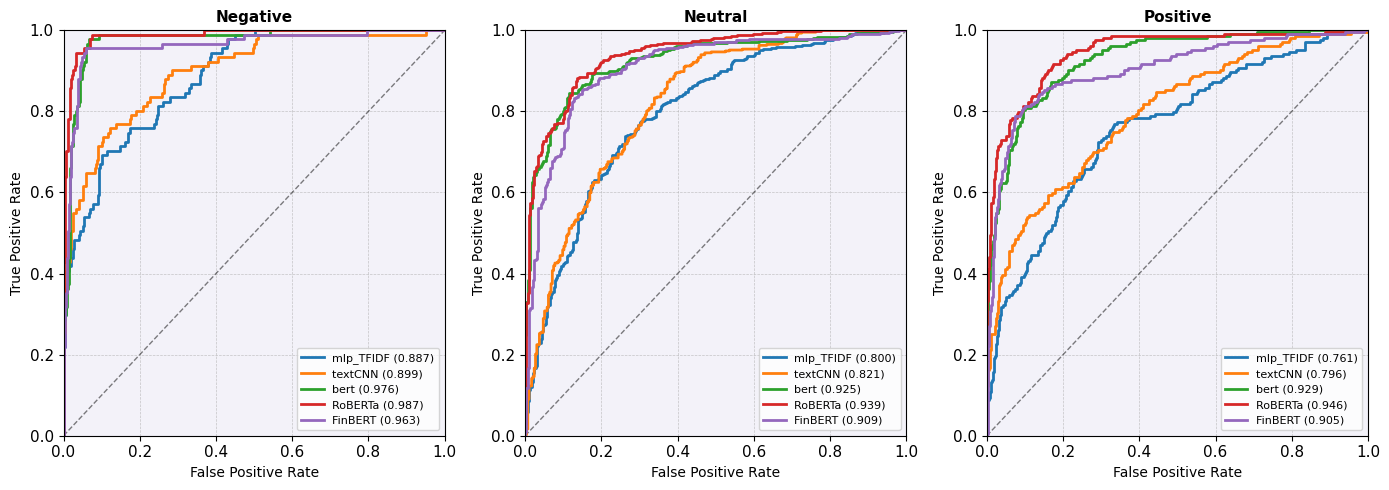

'SAFN_roc_curves.png'

In [21]:
SAFN_res = pd.read_csv('/kaggle/working/SAFN/all_models_roc_data.csv')
plot_all_models_roc_curves(SAFN_res, 'SAFN_roc_curves.png')

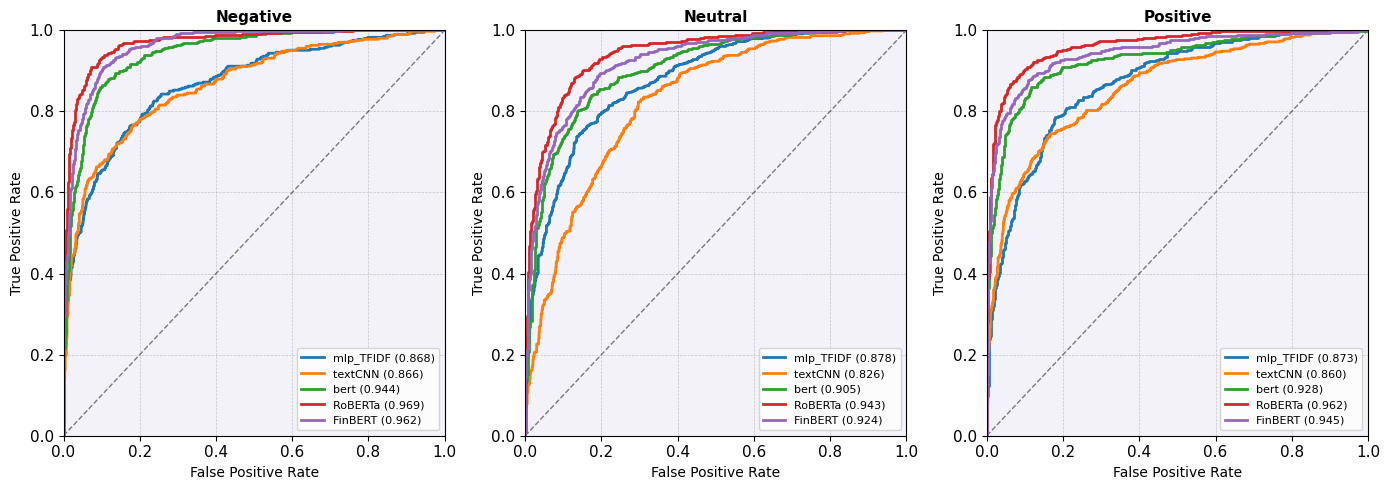

'SEntFiN_roc_curves.png'

In [22]:
SEntFiN_res = pd.read_csv('/kaggle/working/SEntFiN/all_models_roc_data.csv')
plot_all_models_roc_curves(SEntFiN_res, 'SEntFiN_roc_curves.png')

In [23]:
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10

def plot_model_confusion(model_name, data_paths, dataset_names, label_mapping=None):
    """
    More compact confusion matrix plot
    """
    fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))  # Slightly shorter
    
    for idx, (data_path, dataset_name) in enumerate(zip(data_paths, dataset_names)):
        if not os.path.exists(data_path):
            axes[idx].axis('off')
            continue
            
        df = pd.read_csv(data_path)
        model_data = df[df['model'] == model_name]
        
        if len(model_data) == 0:
            axes[idx].axis('off')
            continue
        
        labels = sorted(set(model_data['true_label'].unique()) | 
                       set(model_data['pred_label'].unique()))
        
        cm = confusion_matrix(model_data['true_label'], 
                             model_data['pred_label'], 
                             labels=labels)
        cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        cm_normalized = np.nan_to_num(cm_normalized, nan=0.0)
        
        if label_mapping is not None:
            tick_labels = [label_mapping.get(label, str(label)) for label in labels]
        else:
            tick_labels = [str(label) for label in labels]
        
        sns.heatmap(cm_normalized, 
                   annot=True, 
                   fmt=".2f", 
                   cmap="Blues",
                   cbar=True,
                   square=True,
                   linewidths=0.5,
                   linecolor='gray',
                   ax=axes[idx],
                   xticklabels=tick_labels,
                   yticklabels=tick_labels,
                   cbar_kws={"shrink": 0.7})  # Smaller colorbar
        
        axes[idx].set_xlabel('Pred', fontsize=9)
        axes[idx].set_ylabel('True', fontsize=9)
        axes[idx].set_title(dataset_name, fontsize=10, pad=0.5)  # Minimal padding
        
        axes[idx].tick_params(axis='both', length=0)
    
    fig.suptitle(f"{model_name}", fontsize=11, y=0.4)  # Even tighter
    plt.tight_layout(pad=1.5)  # Minimal padding
    return fig



Models found: ['FinBERT', 'bert', 'mlp_TFIDF', 'textCNN', 'RoBERTa']

Plotting: FinBERT


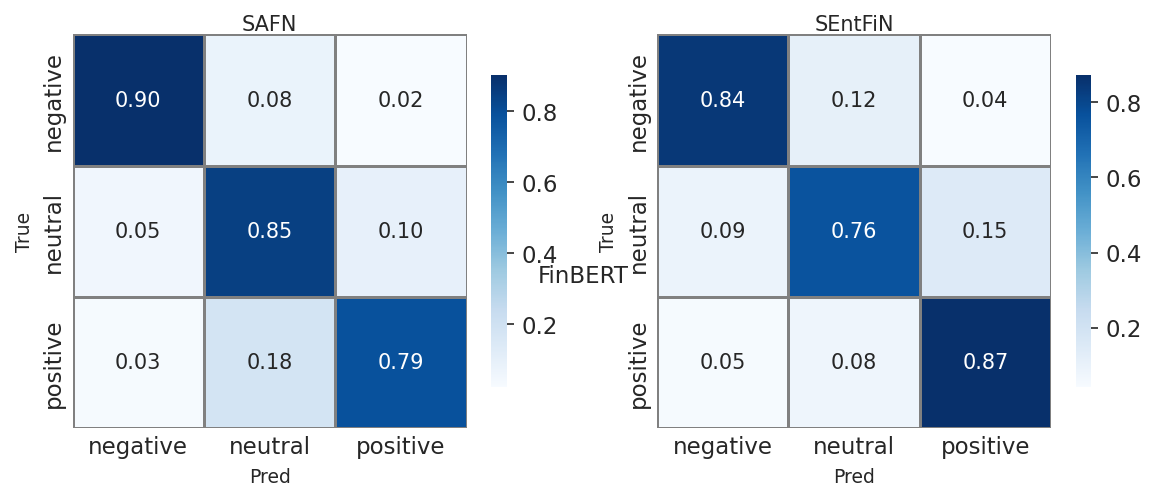


Plotting: bert


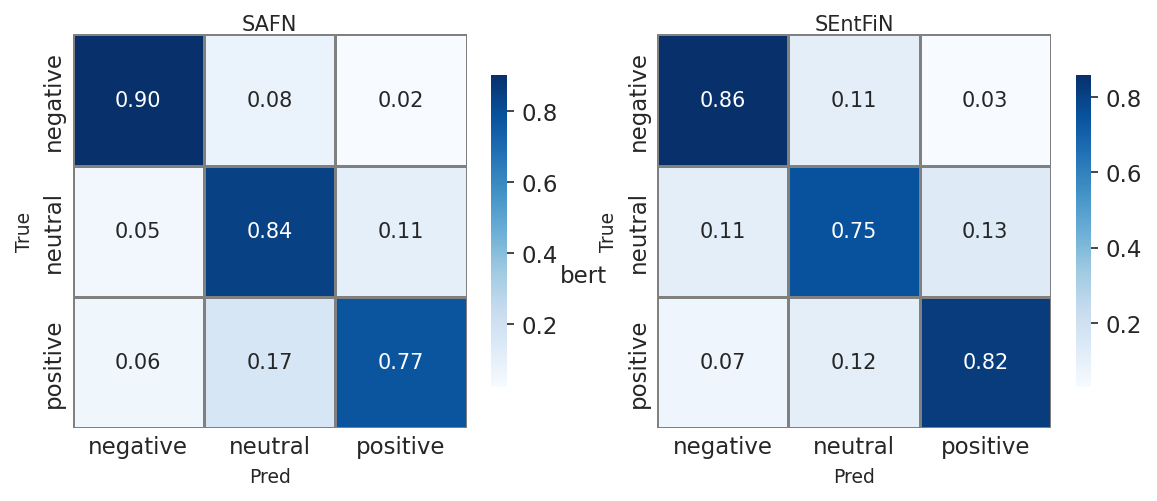


Plotting: mlp_TFIDF


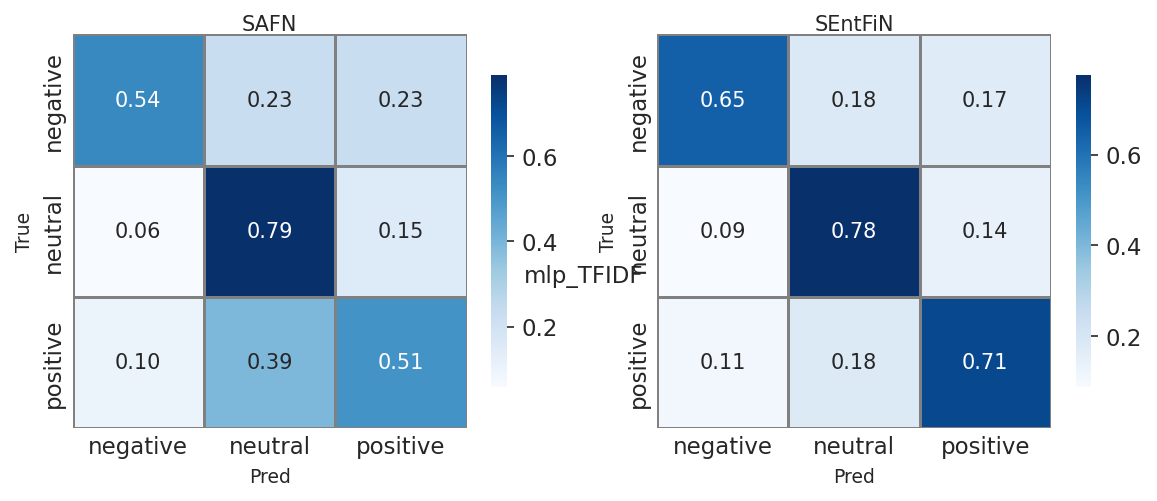


Plotting: textCNN


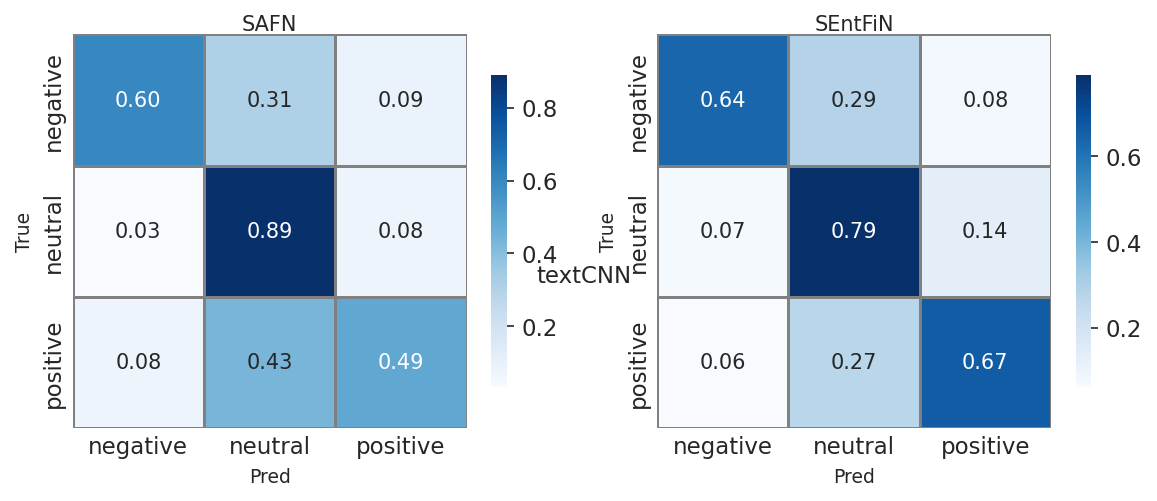


Plotting: RoBERTa


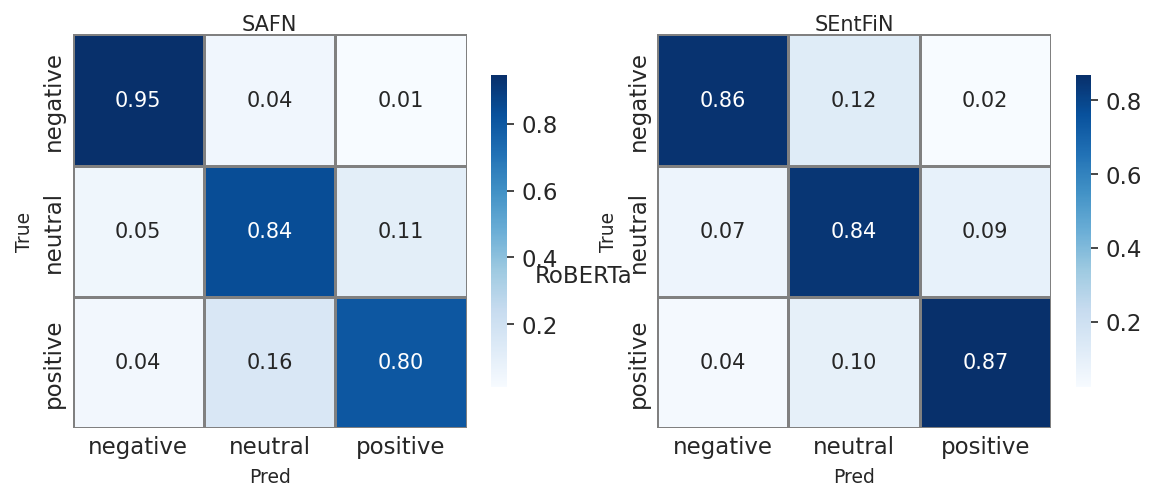


All confusion matrices plotted successfully.


In [24]:
# Configuration
data_paths = [
    '/kaggle/working/SAFN/all_models_confusion_data.csv',
    '/kaggle/working/SEntFiN/all_models_confusion_data.csv'
]

dataset_names = ['SAFN', 'SEntFiN']

# Label mapping
label_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}

# Find all models
all_models = set()
for path in data_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        all_models.update(df['model'].unique())

print(f"Models found: {list(all_models)}")

# Plot for each model
for model in all_models:
    print(f"\nPlotting: {model}")
    fig = plot_model_confusion(model, data_paths, dataset_names, label_mapping)
    
    if fig is not None:
        save_path = f'/kaggle/working/{model}_confusion_matrices.png'
        fig.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show()
        plt.close(fig)

print("\nAll confusion matrices plotted successfully.")